In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [2]:
totales = pd.read_csv("../../../data/respuestas_fede.csv")
print(totales.shape)

#globales
marmol = totales.loc[totales["escuela"] == "Colegio Modelo Mármol"]
mantovani = totales.loc[totales["escuela"] == "Escuela Nueva Juan Mantovani"]

file_ext = '.png'
dpi_value = 200

(369, 22)


## Link de wpp vs Funcionalidad de Wikipedia

In [3]:
# Boilerplate para generar grafico de link wpp vs funcionalidad wiki
def link_wpp_vs_wiki(df, df_name, agrupando = False, invertir_porcentajes = False):
    link_wpp       = df["link_descarga"]
    wiki_veracidad = df["sobre_wikipedia"]

    def analizar_misc_link_wpp(val):
      if val == "Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.":
          return "Sin Misc."
      if val == "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.":
          return "Con Misc."
      if val == "No sé.":
          return "No sé"
      if val == "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.":
          return "Con Misc."
      if val == "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.":
          return "Con Misc."
    
    def analizar_misc_veracidad_wiki(val):
      if val == "Hace falta investigar más para decidir si la información es verdadera o falsa.":
          return "Sin Misc."
      if val == "Toda la información en el artículo es verdadera porque está verificada.":
          return "Con Misc."
      if val == "No hay forma de saber si la información del artículo es verdadera o falsa.":
          return "Con Misc."
      if val == "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.":
          return "Con Misc."

    if(agrupando):
        link_wpp = link_wpp.apply(analizar_misc_link_wpp)
        labels_link_wpp = [
                    "Con Misc.",
                    "No sé",
                    "Sin Misc.",
                    ]

        wiki_veracidad = wiki_veracidad.apply(analizar_misc_veracidad_wiki)
        labels_wiki_veracidad = [
                        "Sin Misc.",
                        "Con Misc.",
                    ]

        if(not invertir_porcentajes):
            filas    = labels_link_wpp
            columnas = labels_wiki_veracidad

            cross_tab_result = pd.crosstab(link_wpp, wiki_veracidad)
        else:
            filas    = labels_wiki_veracidad
            columnas = labels_link_wpp
            cross_tab_result = pd.crosstab(wiki_veracidad, link_wpp)
        
    else:
        labels_link_wpp = [
                 "Seguros.\n Verificados\n por personas",
                 "Seguros.\nVerificados\n por filtro\n inteligente", 
                 "Si es de mis\n contactos\n es seguro", 
                 "No sé", 
                 "No sabemos\n si es seguro",
                ]
        labels_wiki_veracidad = [
                    "Hay que\ninvestigar\nmás",
                    "Todo es\nverdad", 
                    "Todo es\nfalso", 
                    "Inverificable", 
                   ]
        rename_link_wpp = { "Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                            "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                            "No sé.": "No sé",
                            "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                            "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"
                            }
        rename_veracidad_wiki = {"Hace falta investigar más para decidir si la información es verdadera o falsa."     : "Hay que\ninvestigar\nmás",
                                 "Toda la información en el artículo es verdadera porque está verificada."            : "Todo es\nverdad",
                                 "No hay forma de saber si la información del artículo es verdadera o falsa."         : "Inverificable",
                                 "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"
                                 }
        if(not invertir_porcentajes):
            filas = labels_link_wpp
            columnas = labels_wiki_veracidad
            cross_tab_result = pd.crosstab(link_wpp, wiki_veracidad)
            cross_tab_result = cross_tab_result.rename(index=rename_link_wpp, columns=rename_veracidad_wiki)
        else:
            filas = labels_wiki_veracidad
            columnas = labels_link_wpp
            cross_tab_result = pd.crosstab(wiki_veracidad, link_wpp)
            cross_tab_result = cross_tab_result.rename(index=rename_veracidad_wiki, columns=rename_link_wpp)

    cross_tab_result = cross_tab_result.reindex(filas, columns=columnas)

    def agregar_totales(fila):
       res = 0
       for i in list(range(0,fila.size)):
            res = res + fila[i]
       return res
    
    def dividir(fila):
       return fila.div(fila[fila.size - 1])

    cross_tab_result['totales'] = cross_tab_result.apply(agregar_totales, axis=1)
    cross_tab_result = cross_tab_result.apply(dividir, axis=1)
    cross_tab_result = cross_tab_result.drop(['totales'], axis=1)


    if(not invertir_porcentajes):
        titulo_filas = 'Link Wpp'
        titulo_columnas = 'Veracidad Wikipedia'
    else:
        titulo_filas = 'Veracidad Wikipedia'
        titulo_columnas = 'Link Wpp'

    sns.heatmap(cross_tab_result, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5, vmin=0.0, vmax=1.0)
    plt.title('Relación de Respuestas\nLink en wpp vs Veracidad Wikipedia\nDatos {} - Agrupando {} - Invirtiendo {}'.format(df_name,agrupando,invertir_porcentajes))
    # filas
    plt.ylabel(titulo_filas)
    plt.yticks(rotation=0)
    # columnas
    plt.xlabel(titulo_columnas)
    plt.xticks(rotation=0)
    # plt.show()
    plt.savefig('link_wpp_vs_wiki_{}_agrupando_{}_invirtiendo_{}'.format(df_name,agrupando,invertir_porcentajes)+file_ext, bbox_inches='tight', dpi=dpi_value)
    plt.clf()

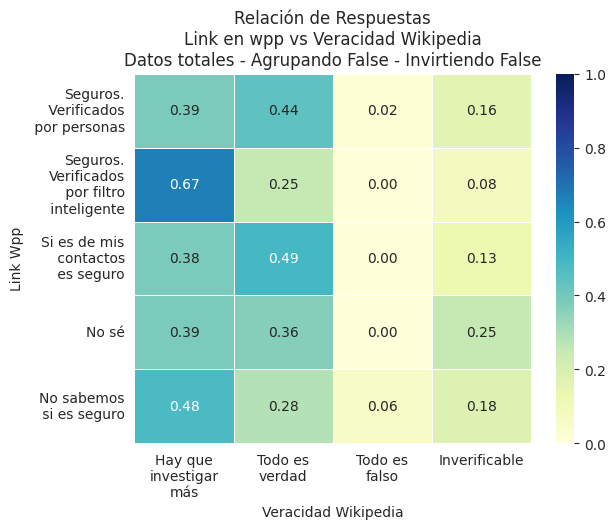

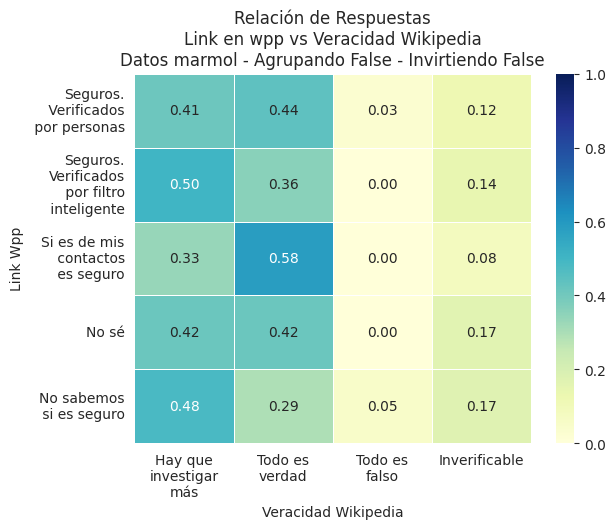

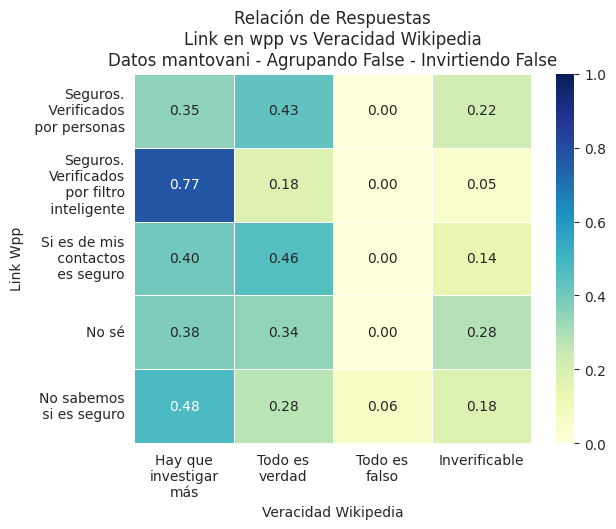

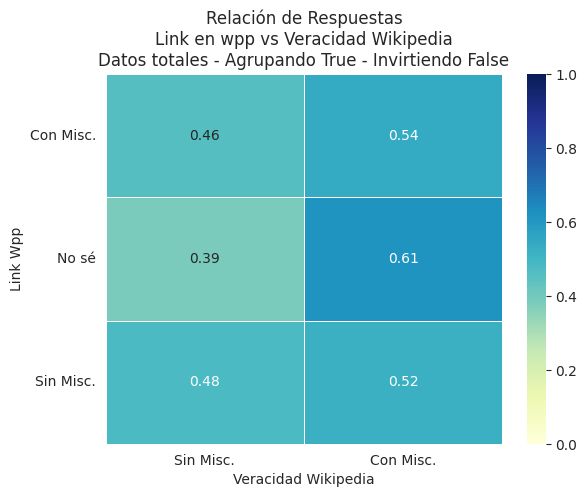

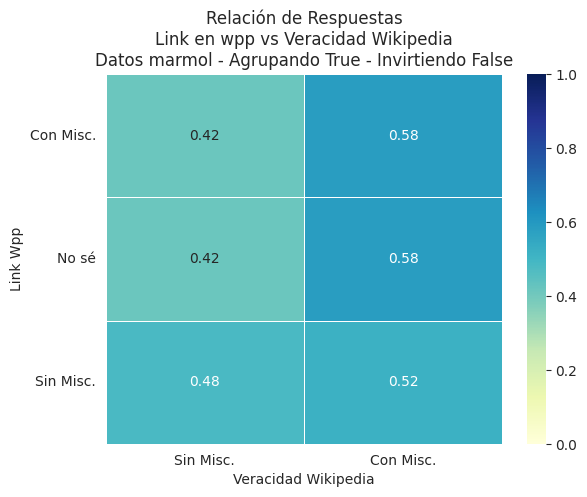

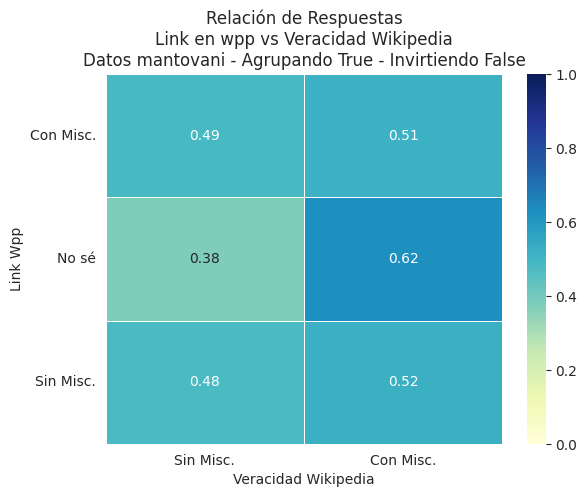

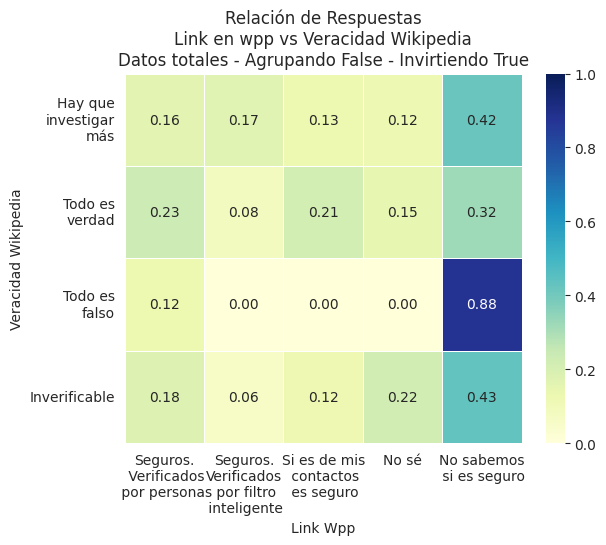

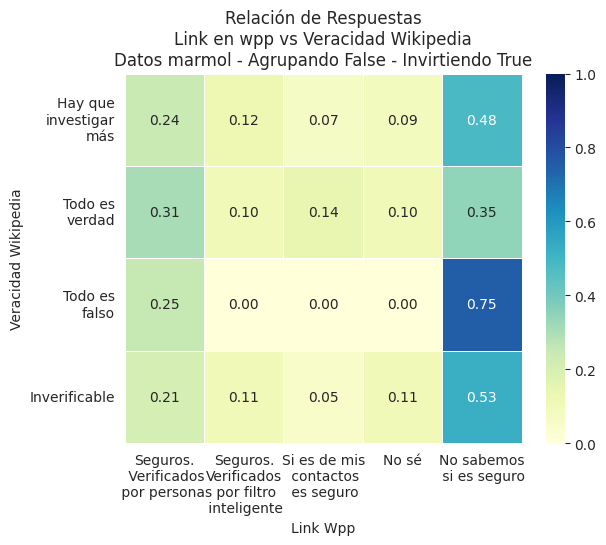

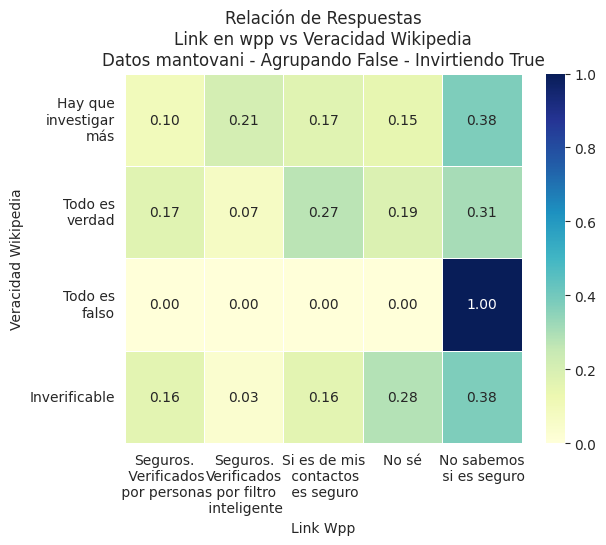

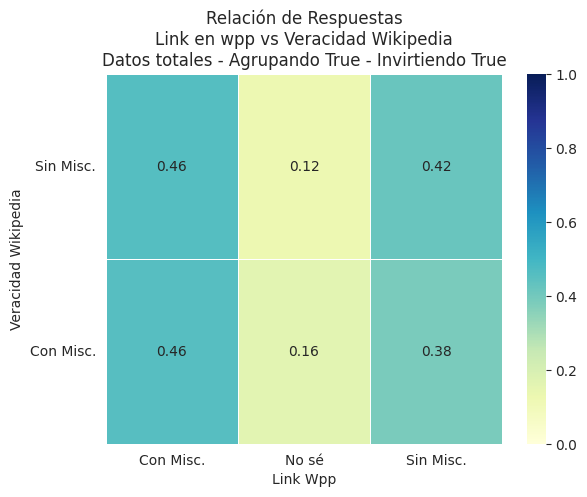

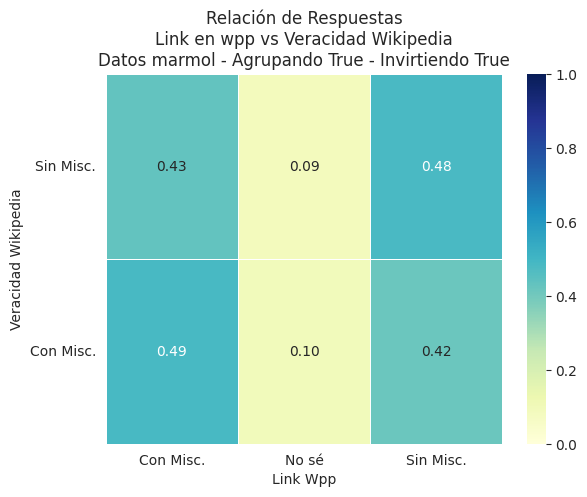

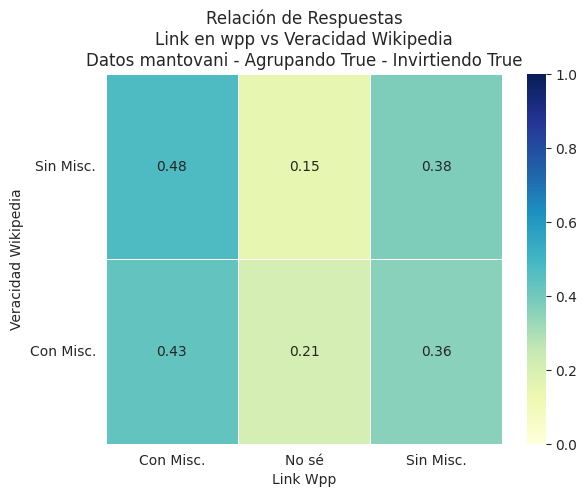

<Figure size 640x480 with 0 Axes>

In [4]:
# llamo al generador de graficos con los tres dfs
link_wpp_vs_wiki(totales, "totales")
link_wpp_vs_wiki(marmol, "marmol")
link_wpp_vs_wiki(mantovani, "mantovani")

# Agrupando misc
link_wpp_vs_wiki(totales,   "totales", True)
link_wpp_vs_wiki(marmol,    "marmol", True)
link_wpp_vs_wiki(mantovani, "mantovani", True)

# Invirtiendo
link_wpp_vs_wiki(totales,   "totales",   invertir_porcentajes=True)
link_wpp_vs_wiki(marmol,    "marmol",    invertir_porcentajes=True)
link_wpp_vs_wiki(mantovani, "mantovani", invertir_porcentajes=True)

# Agrupando misc e Invirtiendo
link_wpp_vs_wiki(totales,   "totales",  agrupando=True, invertir_porcentajes=True)
link_wpp_vs_wiki(marmol,    "marmol",   agrupando=True, invertir_porcentajes=True)
link_wpp_vs_wiki(mantovani, "mantovani",agrupando=True, invertir_porcentajes=True)
